<a href="https://colab.research.google.com/github/IAISA/neur265/blob/main/coding_Homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Imaan Ali
*Neur 265*

**03/6/26**


In [2]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [3]:
#import file
patch_seq = pd.read_csv('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv')


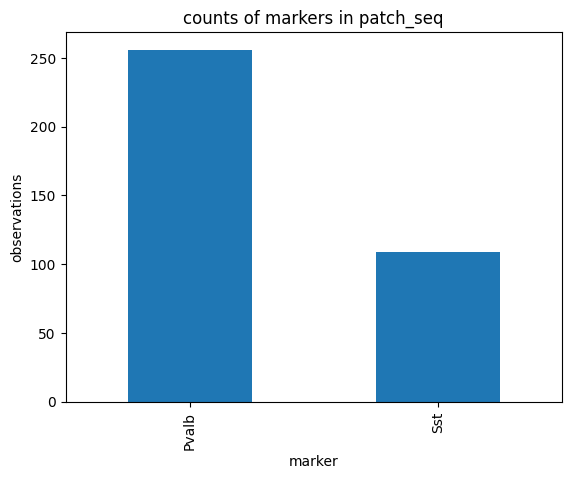

In [4]:
#bar graph
patch_seq['Marker'].value_counts().plot(kind = 'bar')
plt.xlabel('marker')
plt.ylabel('observations')
plt.title('counts of markers in patch_seq')

plt.show()

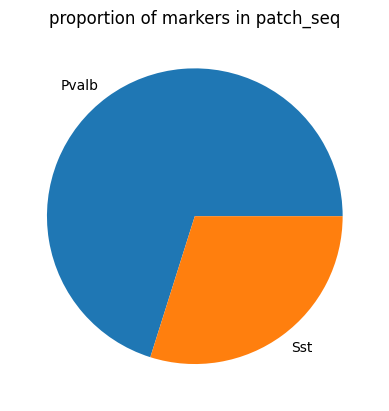

In [5]:
#pie chart

patch_seq['Marker'].value_counts().plot(kind = 'pie')
plt.ylabel('')
plt.title('proportion of markers in patch_seq')

plt.show()

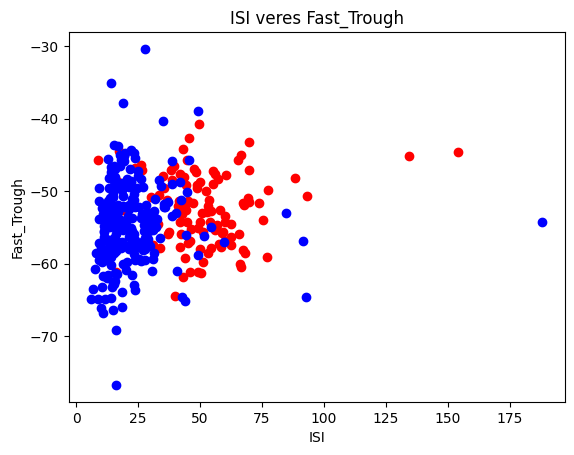

In [6]:
#for loop

for i, row in patch_seq.iterrows():
  if row['Marker'] == 'Sst':
    plt.scatter(row['ISI'], row['Fast_Trough'], color = 'red')
  elif row['Marker'] == 'Pvalb':
    plt.scatter(row['ISI'], row['Fast_Trough'], color='blue')

plt.xlabel('ISI')
plt.ylabel('Fast_Trough')
plt.title('ISI veres Fast_Trough')
plt.show()

In [9]:
#creating the function patchScatter()
def patchScatter():
  for i, row in patch_seq.iterrows():
    if row['Marker'] == 'Sst':
      plt.scatter(row['ISI'], row['Fast_Trough'], color = 'red')
    elif row['Marker'] == 'Pvalb':
      plt.scatter(row['ISI'], row['Fast_Trough'], color='blue')

  plt.xlabel('ISI')
  plt.ylabel('Fast_Trough')
  plt.title('ISI veres Fast_Trough')
  plt.show()


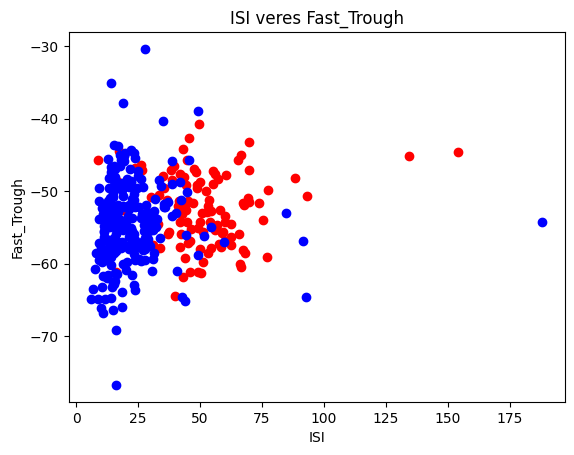

In [10]:
#calling function
patchScatter()

In [12]:
#mean, STD, and range
patch_seq.groupby("Marker")["Fast_Trough"].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


#9 Explanation
The mean for pvalb neurons was -54.55 which is more negative than the mean for Sst neurons at -52.51. A more negative fast trough indicates a stronger undershoot after an action potential i believe so in this case pvalb neurons have a more negative unddershoot.

In [13]:
#skewness of fast_trouph
patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


The skewness for Pvalb is 0.195 and Sst is 0.001 which are both between -.5 and .5 which means that the neuron types are about normal and strongly skewed.

In [14]:
#skewness of ISI
patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


The skewness of pvalb and sst are both greater. than 0.5 indicating for both neuron types are positively skewed and not normally distributed

In [24]:
#t-tests

sst_Neurons = patch_seq[patch_seq['Marker'] == 'Sst']
pvalb_Neurons = patch_seq[patch_seq['Marker'] == 'Pvalb']

stats.ttest_ind(sst_Neurons['Fast_Trough'], pvalb_Neurons['Fast_Trough'])


TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

15. It produced a very small p value less than 0.05, which means that it is a statistically significant difference between Sst and Pvalb neurons.

In [25]:
#remove missing values
sst = sst_Neurons['ISI'].dropna()
pvalb = pvalb_Neurons['ISI'].dropna()

In [26]:
#ttest
stats.ttest_ind(sst,pvalb)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

17. the pvalue is much smaller than 0.5 meaning that it is a statistically significant difference in ISI between Sst and Pvalb neuron